# Applications of AI

# Final Project

## Diabetes Health Indicators Classification

## Part 2: Model Development & Evaluation

### Marianna Kanellaki - S-001081

This notebook covers the comprehensive benchmarking and comparative analysis of machine learning architectures for imbalanced diabetes risk prediction using the BRFSS 2015 public health dataset. The workflow encompasses the end-to-end experimental pipeline, including:

- Data Preprocessing and Imbalance Mitigation: Implementing and benchmarking SMOTE versus algorithmic class weighting strategies.

- Model Benchmarking: Comparative evaluation of classical machine learning (Multinomial Logistic Regression, XGBoost) against state-of-the-art tabular deep learning architectures (MLP, TabNet, and FT-Transformer).

- Hyperparameter Optimization: Utilizing Optuna-driven automated tuning to maximize predictive performance metrics, specifically focusing on Macro F1-score.

- Evaluation and Interpretability: Standardized performance assessment, utilizing custom evaluation routines for One-vs-Rest ROC analysis and feature importance visualization to interpret critical diabetes risk factors.

## Setup & Dependencies

In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
from sklearn.metrics import auc, roc_curve, roc_auc_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from torch.utils.data import DataLoader, TensorDataset
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import xgboost as xgb
import seaborn as sns
import pandas as pd
import numpy as np
import kagglehub
import joblib
import random
import optuna
import torch
import json
import os

/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Reproducibility

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True

In [ ]:
# create dir for saving models
os.makedirs("ckpt", exist_ok=True)

## Dataset Loading & Pre-processing

### Dataset Download

In [5]:
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")
print("Path to dataset files:", path)
print("\nFiles in dataset:")
print(os.listdir(path))

Path to dataset files: /home/marianna/.cache/kagglehub/datasets/alexteboul/diabetes-health-indicators-dataset/versions/1

Files in dataset:
['diabetes_binary_5050split_health_indicators_BRFSS2015.csv', 'diabetes_binary_health_indicators_BRFSS2015.csv', 'diabetes_012_health_indicators_BRFSS2015.csv']


In [6]:
df = pd.read_csv(path+"/diabetes_012_health_indicators_BRFSS2015.csv")
df

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


In [7]:
# clean types according to kaggle description

boolean_cols = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex'
]

categorical_cols = [
    'Diabetes_012',
    'GenHlth',       # 1-5 scale
    'Age',           # 13-level age category
    'Education',     # 1-6 education levels
    'Income'         # 1-8 income brackets
] + boolean_cols # will treat boolean as categorical

integer_cols = [
    'BMI',           # Body Mass Index
    'MentHlth',      # Days of poor mental health in past 30 days
    'PhysHlth'       # Days of poor physical health in past 30 days
]

df[categorical_cols] = df[categorical_cols].astype(int).astype('category')
df[integer_cols] = df[integer_cols].astype(int)

target = 'Diabetes_012'
cat_features = [col for col in categorical_cols if col != target]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   Diabetes_012          253680 non-null  category
 1   HighBP                253680 non-null  category
 2   HighChol              253680 non-null  category
 3   CholCheck             253680 non-null  category
 4   BMI                   253680 non-null  int64   
 5   Smoker                253680 non-null  category
 6   Stroke                253680 non-null  category
 7   HeartDiseaseorAttack  253680 non-null  category
 8   PhysActivity          253680 non-null  category
 9   Fruits                253680 non-null  category
 10  Veggies               253680 non-null  category
 11  HvyAlcoholConsump     253680 non-null  category
 12  AnyHealthcare         253680 non-null  category
 13  NoDocbcCost           253680 non-null  category
 14  GenHlth               253680 non-nul

#### Dataset Split

In [8]:
X = df.drop(columns=['Diabetes_012'])
y = df['Diabetes_012']
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp)

In [9]:
# prepare cross validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

In [10]:
# prepare dictionaries for scoring metrics

multiclass_scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro'),
    'roc_auc': make_scorer(roc_auc_score, response_method='predict_proba', multi_class='ovr')
}

binary_scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro'),
    'roc_auc': make_scorer(roc_auc_score, response_method='predict_proba')
}

### XGBoost Feature Importance

/tmp/ipykernel_5016/1957597232.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


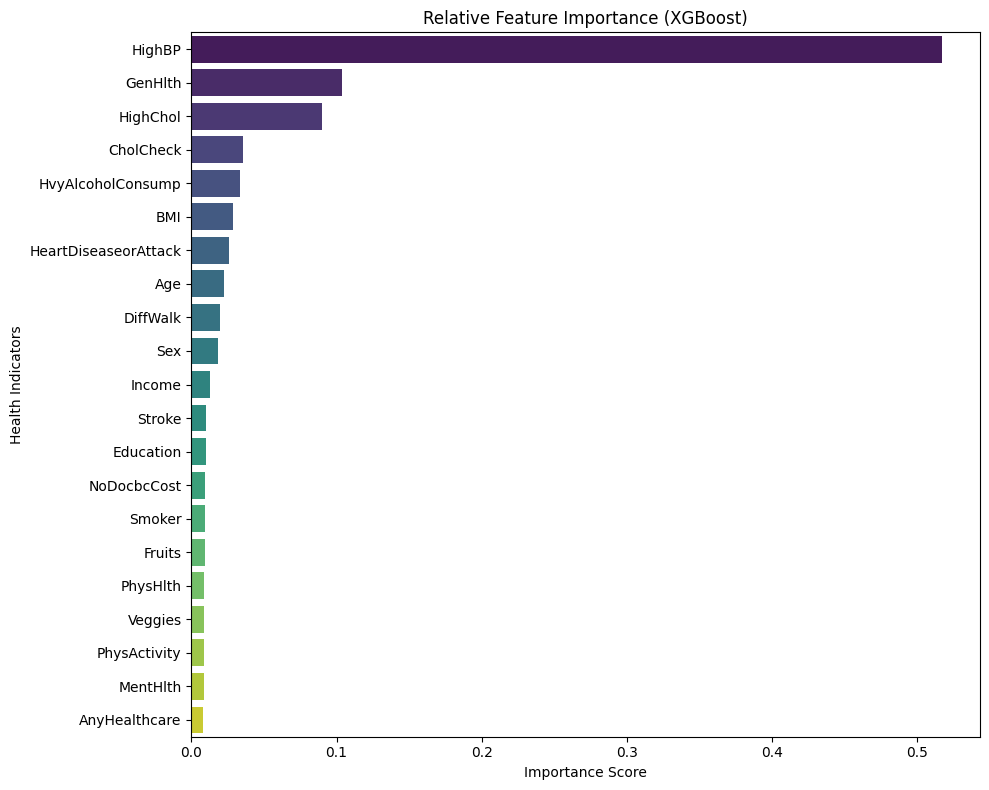

In [ ]:
# quick XGBoost model just to evaluate the features
xgb_selector = xgb.XGBClassifier(
    objective='multi:softmax', 
    num_class=3,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
xgb_selector.fit(X_train, y_train)

# extract and sort feature importances
importances = xgb_selector.feature_importances_
feature_names = X_train.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Relative Feature Importance (XGBoost)')
plt.xlabel('Importance Score')
plt.ylabel('Health Indicators')
plt.tight_layout()
plt.savefig('fig_feature_imp.png', dpi=300)
plt.show()

# keep the 16 most important features
top_features = feature_imp_df['Feature'].head(16).tolist()

X_train_clean = X_train[top_features]
X_test_clean = X_test[top_features]
X_val_clean = X_val[top_features]

While linear correlation analysis (conducted in Part1) provided foundational clinical insights, it also highlighted the overlapping nature of the health markers across the three target classes. Consequently, to ensure non-linear interactions were appropriately captured and low-variance indicators were filtered, XGBoost feature importance was used for the final feature selection prior to deep learning evaluation.

### 1. Baseline Model - Logistic Regression

#### 1.1 Binary Simple Logistic Regression

In [12]:
y_train_binary = y_train.replace({2.0: 1.0})
y_test_binary = y_test.replace({2.0: 1.0})

simple_binary_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))
])

# finetune regularization using grid search with cross-validation
param_grid = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

simple_binary_cv = GridSearchCV(
    simple_binary_pipeline, 
    param_grid, 
    cv=cv_strategy, 
    scoring=binary_scoring, 
    n_jobs=-1,
    refit='f1'
)

simple_binary_cv.fit(X_train, y_train_binary)

results_b = simple_binary_cv.cv_results_
best_index_b = simple_binary_cv.best_index_

print(f"\nBest Logistic Regression Parameters Found: {simple_binary_cv.best_params_}")

simple_binary_logreg_results = {
    'model': 'Logistic Regression (Binary)',
    'accuracy': results_b['mean_test_accuracy'][best_index_b],
    'precision': results_b['mean_test_precision'][best_index_b],
    'recall': results_b['mean_test_recall'][best_index_b],
    'f1': results_b['mean_test_f1'][best_index_b],
    'roc_auc': results_b['mean_test_roc_auc'][best_index_b]
}

simple_binary_logreg_results

/tmp/ipykernel_5016/3326651206.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  y_train_binary = y_train.replace({2.0: 1.0})
/tmp/ipykernel_5016/3326651206.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  y_test_binary = y_test.replace({2.0: 1.0})



Best Logistic Regression Parameters Found: {'logreg__C': 1}


{'model': 'Logistic Regression (Binary)',
 'accuracy': np.float64(0.8481502320675544),
 'precision': np.float64(0.7094734042249699),
 'recall': np.float64(0.5788741804350257),
 'f1': np.float64(0.5966546967090656),
 'roc_auc': np.float64(0.8176930926371423)}

#### 1.2 Multi-class Simple Logistic Regression

In [13]:
simple_multiclass_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        max_iter=1000,
        solver='lbfgs',
        random_state=RANDOM_SEED
    ))
])

# finetune regularization using grid search with cross-validation
param_grid = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

simple_multi_cv = GridSearchCV(
    simple_multiclass_pipeline, 
    param_grid, 
    cv=cv_strategy, 
    scoring=multiclass_scoring, 
    n_jobs=-1,
    refit='f1'
)

simple_multi_cv.fit(X_train, y_train)

results_m = simple_multi_cv.cv_results_
best_index_m = simple_multi_cv.best_index_

print(f"\nBest Logistic Regression Parameters Found: {simple_multi_cv.best_params_}")

simple_logreg_results = {
    'model': 'Logistic Regression (Multiclass)',
    'accuracy': results_m['mean_test_accuracy'][best_index_m],
    'precision': results_m['mean_test_precision'][best_index_m],
    'recall': results_m['mean_test_recall'][best_index_m],
    'f1': results_m['mean_test_f1'][best_index_m],
    'roc_auc': results_m['mean_test_roc_auc'][best_index_m]
}

simple_logreg_results

/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi


Best Logistic Regression Parameters Found: {'logreg__C': 0.1}


{'model': 'Logistic Regression (Multiclass)',
 'accuracy': np.float64(0.8466818411883926),
 'precision': np.float64(0.4636725224521176),
 'recall': np.float64(0.38424511348039825),
 'f1': np.float64(0.39354440485707387),
 'roc_auc': np.float64(0.780801805056587)}

When running a baseline unweighted model, the algorithm failed to predict the minority classes entirely, resulting in division-by-zero precision errors. This mathematically validated the strict necessity of applying class weights to our advanced models. TODO

#### 1.3 Multi-class Logistic Regression with class weighting

In [14]:
pipeline_weighting = ImbPipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        class_weight='balanced',
        solver='lbfgs',
        max_iter=1000,
        random_state=RANDOM_SEED
    ))
])

param_grid = {'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_weighting = GridSearchCV(
    pipeline_weighting,
    param_grid,
    cv=cv_strategy,
    scoring=multiclass_scoring,
    refit='f1',
    n_jobs=-1
)

grid_weighting.fit(X_train, y_train)

results_w = grid_weighting.cv_results_
best_idx_w = grid_weighting.best_index_

print(f"\nBest Logistic Regression Parameters Found: {grid_weighting.best_params_}")

weighting_logreg_results = {
    'model': 'Logistic Regression (Class Weighting)',
    'accuracy': results_w['mean_test_accuracy'][best_idx_w],
    'precision': results_w['mean_test_precision'][best_idx_w],
    'recall': results_w['mean_test_recall'][best_idx_w],
    'f1': results_w['mean_test_f1'][best_idx_w],
    'roc_auc': results_w['mean_test_roc_auc'][best_idx_w]
}

weighting_logreg_results


Best Logistic Regression Parameters Found: {'logreg__C': 0.001}


{'model': 'Logistic Regression (Class Weighting)',
 'accuracy': np.float64(0.645833337208064),
 'precision': np.float64(0.4453650607977638),
 'recall': np.float64(0.5153782449975861),
 'f1': np.float64(0.426147447618462),
 'roc_auc': np.float64(0.7735344207891148)}

#### 1.4 Multi-class Logistic Regression with SMOTE

In [15]:
pipeline_smote = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_SEED)), 
    ('logreg', LogisticRegression(max_iter=1000, solver='lbfgs', random_state=RANDOM_SEED))
])

grid_smote = GridSearchCV(
    pipeline_smote,
    param_grid,
    cv=cv_strategy,
    scoring=multiclass_scoring,
    refit='f1',
    n_jobs=-1
)

grid_smote.fit(X_train, y_train)

results_s = grid_smote.cv_results_
best_idx_s = grid_smote.best_index_

print(f"\nBest Logistic Regression Parameters Found: {grid_smote.best_params_}")

smote_logreg_results = {
    'model': 'Logistic Regression (SMOTE)',
    'accuracy': results_s['mean_test_accuracy'][best_idx_s],
    'precision': results_s['mean_test_precision'][best_idx_s],
    'recall': results_s['mean_test_recall'][best_idx_s],
    'f1': results_s['mean_test_f1'][best_idx_s],
    'roc_auc': results_s['mean_test_roc_auc'][best_idx_s]}

smote_logreg_results


Best Logistic Regression Parameters Found: {'logreg__C': 0.001}


{'model': 'Logistic Regression (SMOTE)',
 'accuracy': np.float64(0.641378906161614),
 'precision': np.float64(0.4461743852662542),
 'recall': np.float64(0.5153028517712627),
 'f1': np.float64(0.4250196152185716),
 'roc_auc': np.float64(0.7705200732186448)}

#### 1.5 Multi-class Logistic Regression with class weighting and only selected features

In [19]:
pipeline_weighting = ImbPipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        class_weight='balanced',
        solver='lbfgs',
        max_iter=1000,
        random_state=RANDOM_SEED
    ))
])

param_grid = {'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_weighting_clean = GridSearchCV(
    pipeline_weighting,
    param_grid,
    cv=cv_strategy,
    scoring=multiclass_scoring,
    refit='f1',
    n_jobs=-1
)

grid_weighting_clean.fit(X_train_clean, y_train)

results_wc = grid_weighting_clean.cv_results_
best_idx_wc = grid_weighting_clean.best_index_

print(f"\nBest Logistic Regression Parameters Found: {grid_weighting_clean.best_params_}")

weighting_clean_logreg_results = {
    'model': 'Logistic Regression (Class Weighting & Feature Selection)',
    'accuracy': results_wc['mean_test_accuracy'][best_idx_wc],
    'precision': results_wc['mean_test_precision'][best_idx_wc],
    'recall': results_wc['mean_test_recall'][best_idx_wc],
    'f1': results_wc['mean_test_f1'][best_idx_wc],
    'roc_auc': results_wc['mean_test_roc_auc'][best_idx_wc]
}

weighting_clean_logreg_results


Best Logistic Regression Parameters Found: {'logreg__C': 0.001}


{'model': 'Logistic Regression (Class Weighting & Feature Selection)',
 'accuracy': np.float64(0.6464739059421566),
 'precision': np.float64(0.44560834063352217),
 'recall': np.float64(0.517109353845668),
 'f1': np.float64(0.42669163674936356),
 'roc_auc': np.float64(0.7735755012720898)}

#### Logistic Regression Comparison

In [82]:
results_df = pd.DataFrame([
    simple_binary_logreg_results,
    simple_logreg_results,
    weighting_logreg_results,
    smote_logreg_results,
    weighting_clean_logreg_results
])

results_df.round(4)

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (Binary),0.8482,0.7095,0.5789,0.5967,0.8177
1,Logistic Regression (Multiclass),0.8467,0.4637,0.3842,0.3935,0.7808
2,Logistic Regression (Class Weighting),0.6458,0.4454,0.5154,0.4261,0.7735
3,Logistic Regression (SMOTE),0.6414,0.4462,0.5153,0.4250,0.7705
4,Logistic Regression (Class Weighting & Feature...,0.6465,0.4456,0.5171,0.4267,0.7736


The baseline Logistic Regression results reveal the class imbalance challenge within the dataset. While the standard multiclass model achieves a high overall accuracy (0.8467), it exhibits poor macro recall (0.3842) and F1-score (0.3935), indicating a strong predictive bias toward the majority class at the expense of minority health categories. Implementing imbalance mitigation techniques successfully addresses this bias: both Class Weighting and SMOTE drastically improve recall to approximately 0.515 and F1-scores to roughly 0.425, with an expected drop in nominal accuracy (to ~0.64). Because Class Weighting and SMOTE yielded virtually identical predictive performance, Class Weighting is selected as the primary imbalance strategy moving forward due to its superior computational efficiency, as it adjusts the loss function without artificially inflating the dataset size. Furthermore, integrating Feature Selection alongside Class Weighting achieved the highest overall multiclass F1-score (0.4267). Consequently, the subsequent modeling phases will proceed utilizing the reduced, XGBoost-selected feature space combined with class-weighted objectives to optimize both minority-class detection and computational efficiency.

### 2. XGBoost

In [21]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_base = xgb.XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=RANDOM_SEED,
    enable_categorical=True
)

# HPO using grid search with cross-validation
param_grid_xgb = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200]
}

grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=cv_strategy,
    scoring=multiclass_scoring,
    refit='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_xgb.fit(X_train_clean, y_train, sample_weight=sample_weights)
best_xgb_model = grid_search_xgb.best_estimator_
print(f"\nBest XGBoost Parameters Found: {grid_search_xgb.best_params_}")

best_index_xgb = grid_search_xgb.best_index_
best_idx_xgb = grid_search_xgb.best_index_
xgb_results = {
    'model': 'XGBoost',
    'accuracy': grid_search_xgb.cv_results_['mean_test_accuracy'][best_idx_xgb],
    'precision': grid_search_xgb.cv_results_['mean_test_precision'][best_idx_xgb],
    'recall': grid_search_xgb.cv_results_['mean_test_recall'][best_idx_xgb],
    'f1': grid_search_xgb.cv_results_['mean_test_f1'][best_idx_xgb],
    'roc_auc': grid_search_xgb.cv_results_['mean_test_roc_auc'][best_idx_xgb]
}

xgb_results

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best XGBoost Parameters Found: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


{'model': 'XGBoost',
 'accuracy': np.float64(0.5214382552889769),
 'precision': np.float64(0.5133594882381262),
 'recall': np.float64(0.5214382460338148),
 'f1': np.float64(0.5119153562728753),
 'roc_auc': np.float64(0.7124975390616158)}

In [83]:
results_df = pd.concat([results_df, pd.DataFrame(xgb_results, index=[5])])
results_df

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (Binary),0.848150,0.709473,0.578874,0.596655,0.817693
1,Logistic Regression (Multiclass),0.846682,0.463673,0.384245,0.393544,0.780802
2,Logistic Regression (Class Weighting),0.645833,0.445365,0.515378,0.426147,0.773534
3,Logistic Regression (SMOTE),0.641379,0.446174,0.515303,0.425020,0.770520
4,Logistic Regression (Class Weighting & Feature...,0.646474,0.445608,0.517109,0.426692,0.773576
5,XGBoost,0.521438,0.513359,0.521438,0.511915,0.712498


When benchmarking the baseline models against the optimized XGBoost architecture, the results reveal a nuanced trade-off between standard classification metrics and discriminative ability. The Logistic Regression (Binary) baseline achieved the highest overall performance across most metrics, with an F1-score of 0.5967 and an ROC-AUC of 0.8177. In comparison, the optimized XGBoost architecture demonstrated a Macro F1-score of 0.5119, which outperforms the multiclass Logistic Regression variants, but it exhibits a lower ROC-AUC (0.7125) and lower overall accuracy (0.5214) than the top-performing linear baseline. While XGBoost remains a potent tool for capturing non-linear feature interactions, these results indicate that for this specific BRFSS 2015 cohort, the linear Logistic Regression baseline currently provides a more certain classifier.

### 3. Multi-Layer Perceptron (MLP)

In [23]:
# setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

##### Global data scaling for DL models

In [99]:
scaler = StandardScaler()

X_train_scaled = X_train_clean.copy()
X_val_scaled = X_val_clean.copy()
X_test_scaled = X_test_clean.copy()

X_train_scaled[['BMI']] = scaler.fit_transform(X_train_scaled[['BMI']])
X_val_scaled[['BMI']] = scaler.transform(X_val_scaled[['BMI']])
X_test_scaled[['BMI']] = scaler.transform(X_test_scaled[['BMI']])

# convert scaled dfs into tensors
X_train_tensor = torch.tensor(np.array(X_train_scaled), dtype=torch.float32)
y_train_tensor = torch.tensor(np.array(y_train), dtype=torch.long)

X_val_tensor = torch.tensor(np.array(X_val_scaled), dtype=torch.float32)
y_val_tensor = torch.tensor(np.array(y_val), dtype=torch.long)

X_test_tensor = torch.tensor(np.array(X_test_scaled), dtype=torch.float32)
y_test_tensor = torch.tensor(np.array(y_test), dtype=torch.long)

In [89]:
# compute class weights for CrossEntropyLoss

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)

In [92]:
from mlp import MLP

def objective_mlp(trial):
    """ HPO using Optuna """
    
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    wd = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW", "RMSprop"])
    batch_size = trial.suggest_categorical('batch_size', [128, 256, 512])

    # create DataLoader
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    input_dim = X_train_tensor.shape[1]
    
    # train
    mlp = MLP(input_dim, dropout_rate, lr, wd, optimizer_name, class_weights_tensor).to(device)
    epochs = 100
    
    for epoch in range(epochs):
        mlp.fit_epoch(train_loader, device)
        val_loss = mlp.validate(X_val_tensor, y_val_tensor, device)
        
        if mlp.check_early_stopping(val_loss):
            print(f"Early stopping at epoch {epoch}")
            break

    # evaluate
    _, _, metrics = mlp.predict_and_evaluate(X_test_tensor, y_test_tensor, device)
    for key, value in metrics.items():
        trial.set_user_attr(key, value)

    if len(trial.study.trials) == 1 or metrics['f1'] > trial.study.best_value:
        joblib.dump(mlp, "ckpt/mlp.pkl")
    
    return metrics['f1']

In [ ]:
study_mlp = optuna.create_study(direction="maximize", study_name="MLP", storage="sqlite:///optuna_mlp.db", load_if_exists=True)
study_mlp.optimize(objective_mlp, n_trials=50)

best_trial_mlp = study_mlp.best_trial

mlp_results = {
    'model': 'MLP',
    'accuracy': best_trial_mlp.user_attrs['accuracy'],
    'precision': best_trial_mlp.user_attrs['precision'],
    'recall': best_trial_mlp.user_attrs['recall'],
    'f1': best_trial_mlp.user_attrs['f1'],
    'roc_auc': best_trial_mlp.user_attrs['roc_auc']
}

print(f"\nBest Parameters Found: {best_trial_mlp.params}")

print(f"Accuracy:  {mlp_results['accuracy']:.4f}")
print(f"Precision: {mlp_results['precision']:.4f}")
print(f"Recall:    {mlp_results['recall']:.4f}")
print(f"F1-Score:  {mlp_results['f1']:.4f}")
print(f"ROC-AUC:   {mlp_results['roc_auc']:.4f}")

[I 2026-06-29 16:54:16,654] Using an existing study with name 'MLP' instead of creating a new one.
[I 2026-06-29 16:54:34,957] Trial 50 finished with value: 0.4057535488757488 and parameters: {'dropout_rate': 0.46973511200429147, 'lr': 0.005843986658860398, 'weight_decay': 3.1208937351142426e-06, 'optimizer': 'RMSprop', 'batch_size': 128}. Best is trial 18 with value: 0.4611587621780231.


Early stopping at epoch 4


[I 2026-06-29 16:54:48,112] Trial 51 finished with value: 0.44395230516061873 and parameters: {'dropout_rate': 0.35845091966547027, 'lr': 0.006404163331827221, 'weight_decay': 9.871610833752432e-05, 'optimizer': 'Adam', 'batch_size': 256}. Best is trial 18 with value: 0.4611587621780231.


Early stopping at epoch 5


[I 2026-06-29 16:54:57,191] Trial 52 finished with value: 0.3945579711194935 and parameters: {'dropout_rate': 0.3467582662197753, 'lr': 0.007084569335820811, 'weight_decay': 5.810174604143731e-05, 'optimizer': 'Adam', 'batch_size': 256}. Best is trial 18 with value: 0.4611587621780231.


...

Early stopping at epoch 12


[I 2026-06-29 17:11:36,538] Trial 98 finished with value: 0.4431614012228631 and parameters: {'dropout_rate': 0.3746686082348789, 'lr': 0.0024093184592281188, 'weight_decay': 6.578353214309295e-05, 'optimizer': 'Adam', 'batch_size': 128}. Best is trial 18 with value: 0.4611587621780231.


Early stopping at epoch 17


[I 2026-06-29 17:11:50,087] Trial 99 finished with value: 0.40889704125492393 and parameters: {'dropout_rate': 0.38576810566055875, 'lr': 0.0018723685791041489, 'weight_decay': 3.587095864446974e-05, 'optimizer': 'Adam', 'batch_size': 512}. Best is trial 18 with value: 0.4611587621780231.


Early stopping at epoch 8

Best Parameters Found: {'dropout_rate': 0.4126447823989508, 'lr': 0.0018819258796576744, 'weight_decay': 4.030920492997764e-05, 'optimizer': 'Adam', 'batch_size': 128}
Accuracy:  0.7686
Precision: 0.4499
Recall:    0.4966
F1-Score:  0.4612
ROC-AUC:   0.7803


In [94]:
results_df = pd.concat([results_df, pd.DataFrame(mlp_results, index=[6])])
results_df

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (Binary),0.848150,0.709473,0.578874,0.596655,0.817693
1,Logistic Regression (Multiclass),0.846682,0.463673,0.384245,0.393544,0.780802
2,Logistic Regression (Class Weighting),0.645833,0.445365,0.515378,0.426147,0.773534
3,Logistic Regression (SMOTE),0.641379,0.446174,0.515303,0.425020,0.770520
4,Logistic Regression (Class Weighting & Feature...,0.646474,0.445608,0.517109,0.426692,0.773576
5,XGBoost,0.521438,0.513359,0.521438,0.511915,0.712498
6,MLP,0.768606,0.449902,0.496587,0.461159,0.780328


The MLP demonstrated strong performance as a deep learning architecture, achieving a Macro F1-score of 0.4612, which represents the second highest F1-score among the models evaluated in this study (after XGBoost). While the MLP exhibits lower nominal accuracy (0.7686) compared to the unweighted Logistic Regression baselines, this result confirms that the architecture effectively prioritizes minority class representation over majority-class dominance, a critical requirement for imbalanced healthcare datasets. With a competitive ROC-AUC of 0.7803, the MLP serves as a robust non-linear learner that successfully captures complex physiological interactions, positioning it as a superior deep learning benchmark for this diabetes classification task compared to traditional linear approaches.

### 4. TabNet

In [ ]:
from tabnet import TabNet

def objective_tabnet(trial):
    """ HPO using Optuna """
    
    batch_size = trial.suggest_categorical('batch_size', [128, 256, 512])
    n_d = trial.suggest_int("n_d", 8, 64)
    n_steps = trial.suggest_int("n_steps", 3, 10)
    gamma = trial.suggest_float("gamma", 1.0, 2.0)
    lambda_sparse = trial.suggest_float("lambda_sparse", 1e-5, 1e-3, log=True)
    
    tabnet = TabNet(
        n_d,
        n_steps,
        gamma,
        lambda_sparse,
        patience=5,
        max_epochs=100
    )

    sample_weights = np.take(weights, y_train.astype(int))
    tabnet.fit_eval(
        X_train_tensor,
        y_train,
        X_val_tensor,
        y_val,
        batch_size=batch_size,
        class_weights=sample_weights
    )

    # evaluate
    _, _, metrics = tabnet.predict_and_evaluate(X_test_tensor, y_test)
    for key, value in metrics.items():
        trial.set_user_attr(key, value)

    if len(trial.study.trials) == 1 or metrics['f1'] > trial.study.best_value:
        joblib.dump(tabnet, "ckpt/tabnet.pkl")
    
    return metrics['f1']

In [ ]:
study_tabnet = optuna.create_study(direction="maximize", study_name="TabNet", storage="sqlite:///optuna_tabnet.db", load_if_exists=True)
study_tabnet.optimize(objective_tabnet, n_trials=10)

best_trial_tabnet = study_tabnet.best_trial

tabnet_results = {
    'model': 'Tabnet',
    'accuracy': best_trial_tabnet.user_attrs['accuracy'],
    'precision': best_trial_tabnet.user_attrs['precision'],
    'recall': best_trial_tabnet.user_attrs['recall'],
    'f1': best_trial_tabnet.user_attrs['f1'],
    'roc_auc': best_trial_tabnet.user_attrs['roc_auc']
}

print(f"\nBest Parameters Found: {best_trial_tabnet.params}")

print(f"Accuracy:  {tabnet_results['accuracy']:.4f}")
print(f"Precision: {tabnet_results['precision']:.4f}")
print(f"Recall:    {tabnet_results['recall']:.4f}")
print(f"F1-Score:  {tabnet_results['f1']:.4f}")
print(f"ROC-AUC:   {tabnet_results['roc_auc']:.4f}")

[I 2026-06-29 18:16:39,443] Using an existing study with name 'TabNet' instead of creating a new one.
/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.00262 | val_accuracy: 0.55042 | val_logloss: 1.02906 |  0:00:26s
epoch 1  | loss: 0.97327 | val_accuracy: 0.62985 | val_logloss: 0.90201 |  0:00:51s
epoch 2  | loss: 0.96486 | val_accuracy: 0.58724 | val_logloss: 0.9622  |  0:01:17s
epoch 3  | loss: 0.96067 | val_accuracy: 0.61928 | val_logloss: 0.8913  |  0:01:44s
epoch 4  | loss: 0.95909 | val_accuracy: 0.63001 | val_logloss: 0.85123 |  0:02:10s
epoch 5  | loss: 0.95386 | val_accuracy: 0.62453 | val_logloss: 0.86239 |  0:02:35s
epoch 6  | loss: 0.95165 | val_accuracy: 0.61361 | val_logloss: 0.89773 |  0:03:01s
epoch 7  | loss: 0.95396 | val_accuracy: 0.58526 | val_logloss: 0.90894 |  0:03:26s
epoch 8  | loss: 0.95004 | val_accuracy: 0.58956 | val_logloss: 0.89291 |  0:03:53s
epoch 9  | loss: 0.95464 | val_accuracy: 0.58203 | val_logloss: 0.91416 |  0:04:19s

Early stopping occurred at epoch 9 with best_epoch = 4 and best_val_logloss = 0.85123


/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-06-29 18:21:20,864] Trial 63 finished with value: 0.42443302913816017 and parameters: {'batch_size': 256, 'n_d': 10, 'n_steps': 6, 'gamma': 1.6271921969041367, 'lambda_sparse': 0.0003854685317479186}. Best is trial 37 with value: 0.44193633815233563.
/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.99494 | val_accuracy: 0.64715 | val_logloss: 0.86283 |  0:00:53s
epoch 1  | loss: 0.96009 | val_accuracy: 0.67435 | val_logloss: 0.75233 |  0:01:44s
epoch 2  | loss: 0.95461 | val_accuracy: 0.58724 | val_logloss: 0.95111 |  0:02:35s
epoch 3  | loss: 0.95174 | val_accuracy: 0.6302  | val_logloss: 0.87391 |  0:03:28s
epoch 4  | loss: 0.94968 | val_accuracy: 0.53966 | val_logloss: 1.00658 |  0:04:21s
epoch 5  | loss: 0.94914 | val_accuracy: 0.67025 | val_logloss: 0.773   |  0:05:15s
epoch 6  | loss: 0.94416 | val_accuracy: 0.56256 | val_logloss: 0.89063 |  0:06:06s

Early stopping occurred at epoch 6 with best_epoch = 1 and best_val_logloss = 0.75233


/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-06-29 18:28:13,720] Trial 64 finished with value: 0.43849207409637664 and parameters: {'batch_size': 128, 'n_d': 16, 'n_steps': 7, 'gamma': 1.523711427753451, 'lambda_sparse': 0.0006319347340684097}. Best is trial 37 with value: 0.44193633815233563.
/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


...

epoch 0  | loss: 0.99007 | val_accuracy: 0.57781 | val_logloss: 0.98587 |  0:01:00s
epoch 1  | loss: 0.96458 | val_accuracy: 0.59583 | val_logloss: 0.96045 |  0:01:59s
epoch 2  | loss: 0.96184 | val_accuracy: 0.68031 | val_logloss: 0.82781 |  0:02:59s
epoch 3  | loss: 0.95922 | val_accuracy: 0.66371 | val_logloss: 0.86838 |  0:03:58s
epoch 4  | loss: 0.95772 | val_accuracy: 0.5993  | val_logloss: 0.95583 |  0:04:59s
epoch 5  | loss: 0.95837 | val_accuracy: 0.6805  | val_logloss: 0.81827 |  0:06:00s
epoch 6  | loss: 0.95847 | val_accuracy: 0.65453 | val_logloss: 0.85286 |  0:07:00s
epoch 7  | loss: 0.9579  | val_accuracy: 0.65054 | val_logloss: 0.84884 |  0:08:00s
epoch 8  | loss: 0.95654 | val_accuracy: 0.67057 | val_logloss: 0.85165 |  0:09:00s
epoch 9  | loss: 0.95823 | val_accuracy: 0.5855  | val_logloss: 0.98331 |  0:10:00s
epoch 10 | loss: 0.95683 | val_accuracy: 0.62894 | val_logloss: 0.91319 |  0:11:01s

Early stopping occurred at epoch 10 with best_epoch = 5 and best_val_loglos

/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-06-29 19:24:12,208] Trial 71 finished with value: 0.4371533655150459 and parameters: {'batch_size': 128, 'n_d': 14, 'n_steps': 8, 'gamma': 1.126360327204847, 'lambda_sparse': 0.0007960763885031047}. Best is trial 67 with value: 0.45065810254445876.
/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.98358 | val_accuracy: 0.60951 | val_logloss: 0.87376 |  0:01:00s
epoch 1  | loss: 0.96057 | val_accuracy: 0.62863 | val_logloss: 0.82542 |  0:02:01s
epoch 2  | loss: 0.95814 | val_accuracy: 0.603   | val_logloss: 0.85517 |  0:03:03s
epoch 3  | loss: 0.95458 | val_accuracy: 0.61175 | val_logloss: 0.88    |  0:04:04s
epoch 4  | loss: 0.95126 | val_accuracy: 0.60139 | val_logloss: 0.91937 |  0:05:05s
epoch 5  | loss: 0.95087 | val_accuracy: 0.64495 | val_logloss: 0.80266 |  0:06:06s
epoch 6  | loss: 0.95183 | val_accuracy: 0.61022 | val_logloss: 0.86136 |  0:07:06s
epoch 7  | loss: 0.95393 | val_accuracy: 0.63781 | val_logloss: 0.82524 |  0:08:04s
epoch 8  | loss: 0.95058 | val_accuracy: 0.59756 | val_logloss: 0.93949 |  0:09:01s
epoch 9  | loss: 0.95015 | val_accuracy: 0.61806 | val_logloss: 0.88519 |  0:10:00s
epoch 10 | loss: 0.95078 | val_accuracy: 0.57896 | val_logloss: 0.91393 |  0:10:58s

Early stopping occurred at epoch 10 with best_epoch = 5 and best_val_loglos

/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-06-29 19:36:05,964] Trial 72 finished with value: 0.4301498018297818 and parameters: {'batch_size': 128, 'n_d': 15, 'n_steps': 8, 'gamma': 1.0981032392854249, 'lambda_sparse': 0.0009009907661572548}. Best is trial 67 with value: 0.45065810254445876.



Best Parameters Found: {'batch_size': 128, 'n_d': 25, 'n_steps': 5, 'gamma': 1.333210967544579, 'lambda_sparse': 0.0006118846577383933}
Accuracy:  0.7277
Precision: 0.4595
Recall:    0.4996
F1-Score:  0.4507
ROC-AUC:   0.7761


In [118]:
results_df = pd.concat([results_df, pd.DataFrame(tabnet_results, index=[7])])
results_df

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (Binary),0.848150,0.709473,0.578874,0.596655,0.817693
1,Logistic Regression (Multiclass),0.846682,0.463673,0.384245,0.393544,0.780802
2,Logistic Regression (Class Weighting),0.645833,0.445365,0.515378,0.426147,0.773534
3,Logistic Regression (SMOTE),0.641379,0.446174,0.515303,0.425020,0.770520
4,Logistic Regression (Class Weighting & Feature...,0.646474,0.445608,0.517109,0.426692,0.773576
5,XGBoost,0.521438,0.513359,0.521438,0.511915,0.712498
6,MLP,0.768606,0.449902,0.496587,0.461159,0.780328
7,Tabnet,0.727688,0.459508,0.499562,0.450658,0.776070


TabNet achieves an accuracy of approximately 72.77% and an ROC AUC of 0.776, placing it as a competitive middle-tier performer among the evaluated models. While its accuracy is lower than the Logistic Regression Baseline model (~84%), TabNet demonstrates a balanced performance profile, showing better precision (45.95%) and F1 scores (45.07%) than the majority of the model variations. It performs comparably to the MLP architecture, with less accuracy, suggesting that further hyperparameter tuning or feature engineering specifically for the TabNet architecture could help bridge the performance gap with the top-performing linear models.

### 5. FT-Transformer

In [119]:
import tensorflow as tf

In [120]:
tf.random.set_seed(RANDOM_SEED)

In [121]:
numerical_cols = [col for col in X_train_clean.columns if col in integer_cols]
cat_features = [col for col in X_train_clean.columns if col in categorical_cols and col != target]

print('Numerical columns:', numerical_cols)
print('Categorical columns:', cat_features)

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
keras_weights = {classes[i]: weights[i] for i in range(len(classes))}

Numerical columns: ['BMI']
Categorical columns: ['HighBP', 'GenHlth', 'HighChol', 'CholCheck', 'HvyAlcoholConsump', 'HeartDiseaseorAttack', 'Age', 'DiffWalk', 'Sex', 'Income', 'Stroke', 'Education', 'NoDocbcCost', 'Smoker', 'Fruits']


In [ ]:
from fttransformer import FTTransformerWrapper

def objective(trial):
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    depth = trial.suggest_int('depth', 2, 6)
    heads = trial.suggest_categorical('heads', [2, 4, 8])
    embedding_dim = trial.suggest_categorical('embedding_dim', [16, 32, 64])
    batch_size = trial.suggest_categorical('batch_size', [128, 256])

    ftt = FTTransformerWrapper(
        learning_rate=lr,
        depth=depth,
        heads=heads,
        embedding_dim=embedding_dim,
        batch_size=batch_size
    )

    ftt.fit(
        X_train_scaled,
        y_train,
        X_val_scaled,
        y_val,
        num_cols=numerical_cols,
        cat_cols=cat_features,
        epochs=100,
    )

    _, _, metrics = ftt.predict_and_evaluate(X_test_scaled, y_test, numerical_cols, cat_features)
    for key, value in metrics.items():
        trial.set_user_attr(key, value)

    if len(trial.study.trials) == 1 or metrics['f1'] > trial.study.best_value:
        ftt.model.save_weights( "ckpt/ft-transformer.weights.h5")
        losses = {
                    'train_loss': ftt.history.history.get('loss', []),
                    'val_loss': ftt.history.history.get('val_loss', [])
                }

        with open(os.path.join("ckpt", f"ftt_losses.json"), "w") as f:
            json.dump(losses, f)
    
    return metrics['f1']

In [ ]:
y_train = np.asarray(y_train).astype(np.int32)
y_test = np.asarray(y_test).astype(np.int32)

study_ft_transformer = optuna.create_study(direction='maximize', study_name='FTTransformer', storage='sqlite:///optuna_fttransformer.db', load_if_exists=True)
study_ft_transformer.optimize(objective, n_trials=50)

best_trial_ft_transformer = study_ft_transformer.best_trial

ftt_results = {
    'model': 'FT-Transformer',
    'accuracy': best_trial_ft_transformer.user_attrs['accuracy'],
    'precision': best_trial_ft_transformer.user_attrs['precision'],
    'recall': best_trial_ft_transformer.user_attrs['recall'],
    'f1': best_trial_ft_transformer.user_attrs['f1'],
    'roc_auc': best_trial_ft_transformer.user_attrs['roc_auc']
}

print(f"\nBest Parameters Found: {best_trial_ft_transformer.params}")

print(f"Accuracy:  {ftt_results['accuracy']:.4f}")
print(f"Precision: {ftt_results['precision']:.4f}")
print(f"Recall:    {ftt_results['recall']:.4f}")
print(f"F1-Score:  {ftt_results['f1']:.4f}")
print(f"ROC-AUC:   {ftt_results['roc_auc']:.4f}")


I0000 00:00:1782625623.835130   27568 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782625625.521934   27568 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
[I 2026-06-28 07:47:05,938] A new study created in RDB with name: FTTransformer
W0000 00:00:1782625626.469197   27568 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/100


/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'ft_transformer_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


1586/1586 ━━━━━━━━━━━━━━━━━━━━ 249s 151ms/step - accuracy: 0.8438 - loss: 0.4140 - val_accuracy: 0.8471 - val_loss: 0.4043
Epoch 2/100
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 239s 151ms/step - accuracy: 0.8473 - loss: 0.4022 - val_accuracy: 0.8458 - val_loss: 0.4057
Epoch 3/100
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 239s 151ms/step - accuracy: 0.8458 - loss: 0.4061 - val_accuracy: 0.8425 - val_loss: 0.4162
Epoch 4/100
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 239s 150ms/step - accuracy: 0.8426 - loss: 0.4134 - val_accuracy: 0.8424 - val_loss: 0.4145


/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
[I 2026-06-28 08:03:28,639] Trial 0 finished with value: 0.3659638955441202 and parameters: {'lr': 0.002627620800326294, 'depth': 4, 'heads': 4, 'embedding_dim': 64, 'batch_size': 128}. Best is trial 0 with value: 0.3659638955441202.


...

Epoch 1/100


/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'ft_transformer_encoder_49', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


793/793 ━━━━━━━━━━━━━━━━━━━━ 31s 30ms/step - accuracy: 0.8419 - loss: 0.4246 - val_accuracy: 0.8461 - val_loss: 0.4028
Epoch 2/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.8487 - loss: 0.3972 - val_accuracy: 0.8477 - val_loss: 0.3998
Epoch 3/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.8492 - loss: 0.3955 - val_accuracy: 0.8480 - val_loss: 0.3994
Epoch 4/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.8495 - loss: 0.3949 - val_accuracy: 0.8481 - val_loss: 0.3996
Epoch 5/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.8496 - loss: 0.3947 - val_accuracy: 0.8480 - val_loss: 0.3997
Epoch 6/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.8495 - loss: 0.3945 - val_accuracy: 0.8480 - val_loss: 0.3995


/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
[I 2026-06-29 10:53:01,959] Trial 49 finished with value: 0.3745518395760845 and parameters: {'lr': 0.00012456520050885164, 'depth': 2, 'heads': 4, 'embedding_dim': 16, 'batch_size': 256}. Best is trial 48 with value: 0.3970336134655486.



Best Parameters Found: {'lr': 0.00011478910112965757, 'depth': 2, 'heads': 4, 'embedding_dim': 16, 'batch_size': 256}
Accuracy:  0.8501
Precision: 0.4766
Recall:    0.3865
F1-Score:  0.3970
ROC-AUC:   0.7913


### Comparison

In [ ]:
results_df = pd.concat([results_df, pd.DataFrame(ftt_results, index=[8])])
results_df

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (Binary),0.848150,0.709473,0.578874,0.596655,0.817693
1,Logistic Regression (Multiclass),0.846682,0.463673,0.384245,0.393544,0.780802
2,Logistic Regression (Class Weighting),0.645833,0.445365,0.515378,0.426147,0.773534
3,Logistic Regression (SMOTE),0.641379,0.446174,0.515303,0.425020,0.770520
4,Logistic Regression (Class Weighting & Feature...,0.646474,0.445608,0.517109,0.426692,0.773576
5,XGBoost,0.521438,0.513359,0.521438,0.511915,0.712498
6,MLP,0.768606,0.449902,0.496587,0.461159,0.780328
7,Tabnet,0.727688,0.459508,0.499562,0.450658,0.776070
8,FT-Transformer,0.686298,0.440500,0.522431,0.438662,0.776781


The evaluation results highlight a trade-off between standard classical approaches and attention-based neural models. While the Multi-Layer Perceptron (MLP) achieved the highest accuracy among the deep learning group at 0.7686, the FT-Transformer demonstrated superior minority-class detection with a macro recall of 0.5224, significantly outperforming both the MLP (0.4966) and the standard TabNet architecture (0.4996). Although XGBoost remains highly competitive with an F1-score of 0.5119, the FT-Transformer's ability to maintain high sensitivity in the context of severe class imbalance positions it as a robust candidate for clinical risk stratification, even if its overall nominal accuracy (0.6863) is lower than the highly optimized classical ensembles.

## Model Loading and predictions

In [ ]:
from mlp import MLP
from tabnet import TabNet

logreg_model = grid_weighting_clean.best_estimator_
pred_logreg = logreg_model.predict(X_test_clean)
prob_logreg = logreg_model.predict_proba(X_test_clean)

xgb_model = grid_search_xgb.best_estimator_
pred_xgb = xgb_model.predict(X_test_clean)
prob_xgb = xgb_model.predict_proba(X_test_clean)

mlp =  joblib.load('ckpt/mlp.pkl')
pred_mlp, prob_mlp, metrics_mlp = mlp.predict_and_evaluate(X_test_tensor, y_test_tensor, device)

tabnet = joblib.load('ckpt/tabnet.pkl')
pred_tabnet, prob_tabnet, metrics_tabnet = tabnet.predict_and_evaluate(X_test_scaled, y_test)

In [146]:
def load_ft_transformer_model(save_path, num_cols, cat_cols, X_train):
    tf.keras.backend.clear_session()
    
    wrapper_params = {}
    optuna_best_params = study_ft_transformer.best_params

    wrapper_params['learning_rate'] = optuna_best_params.get('lr', optuna_best_params.get('learning_rate', 1e-3))
    wrapper_params['depth'] = optuna_best_params.get('attn_blocks', optuna_best_params.get('depth', 3))
    wrapper_params['heads'] = optuna_best_params.get('num_heads', optuna_best_params.get('heads', 4))
    wrapper_params['attn_dropout'] = optuna_best_params.get('attn_dropout', 0.1)
    wrapper_params['ff_dropout'] = optuna_best_params.get('ff_dropout', 0.1)
    wrapper_params['embedding_dim'] = optuna_best_params.get('embed_dim', optuna_best_params.get('embedding_dim', 32))
    if 'batch_size' in optuna_best_params:
        wrapper_params['batch_size'] = optuna_best_params['batch_size']

        
    ftt_wrapper = FTTransformerWrapper(**wrapper_params)
    ftt_wrapper.build_model(num_cols, cat_cols, X_train) 
    
    train_num = X_train[num_cols].values.astype(np.float32)
    train_cat = X_train[cat_cols].astype(str).values.astype(object)
    
    dummy_input = {col: train_num[0:1, i:i+1] for i, col in enumerate(num_cols)}
    for i, col in enumerate(cat_cols):
        dummy_input[col] = train_cat[0:1, i:i+1]
    
    ftt_wrapper.model(dummy_input)
    ftt_wrapper.model.load_weights(save_path)
    return ftt_wrapper

study_ft_transformer = optuna.create_study(direction='maximize', study_name='FTTransformer', storage='sqlite:///optuna_fttransformer.db', load_if_exists=True)
ftt = load_ft_transformer_model('ckpt/ft-transformer.weights.h5', numerical_cols, cat_features, X_train_scaled)

pred_ftt, prob_ftt, metrics_ftt = ftt.predict_and_evaluate(X_test_scaled, y_test, numerical_cols, cat_features)

[I 2026-06-30 01:37:33,247] Using an existing study with name 'FTTransformer' instead of creating a new one.
/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'ft_transformer_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 108 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [148]:
def plot_combined_roc_curves(y_true, model_probabilities, target_class=1, class_names=["Healthy", "Prediabetes", "Diabetes"]):
    """
    Plots a single ROC curve comparing all models for a specific class (default: Prediabetes).
    
    y_true: array of actual labels
    model_probabilities: dict format {'Model Name': y_prob_array}
    """

    y_test_bin = label_binarize(y_true, classes=[0, 1, 2])
    
    plt.figure(figsize=(10, 8))
    
    for model_name, y_prob in model_probabilities.items():
        fpr, tpr, _ = roc_curve(y_test_bin[:, target_class], y_prob[:, target_class])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'One-vs-Rest ROC Curve Comparison\nTarget Class: {class_names[target_class]}', fontsize=14)
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.savefig('combined_roc_curve.png', dpi=300, bbox_inches='tight')
    plt.show()

In [149]:
def plot_confusion_matrices(y_true, model_predictions, class_names=["Healthy", "Prediabetes", "Diabetes"], normalize='true'):
    """
    Plots confusion matrices in a 2-row layout for 5 models.
    
    y_true: array of actual labels
    model_predictions: dict format {'Model Name': y_pred_array}
    """
    model_names = list(model_predictions.keys())
    num_models = len(model_names)
    
    # 2 rows, 3 columns
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for i in range(len(axes)):
        if i < num_models:
            model_name = model_names[i]
            y_pred = model_predictions[model_name]
            ax = axes[i]
            
            cm = confusion_matrix(y_true, y_pred, normalize=normalize)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
            
            values_format = '.2%' if normalize else 'd'
            disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format=values_format)
            
            ax.set_title(f'{model_name}')
            ax.grid(False)
        else:
            axes[i].axis('off')

    plt.tight_layout()
    plt.savefig('combined_confusion_matrices.png', dpi=300, bbox_inches='tight')
    plt.show()

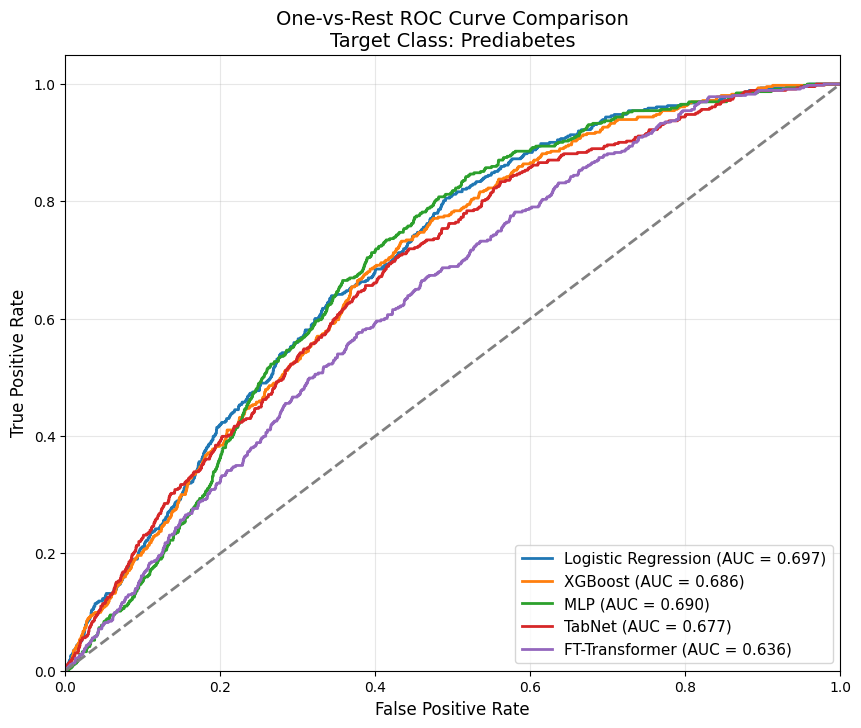

In [150]:
probs_dict = {
    'Logistic Regression': prob_logreg,
    'XGBoost': prob_xgb,
    'MLP': prob_mlp,
    'TabNet': prob_tabnet,
    'FT-Transformer': prob_ftt
}
plot_combined_roc_curves(y_test, probs_dict)

Based on the ROC curve analysis for the "Prediabetes" target class, the models demonstrate comparable discriminative performance with AUC scores clustered between 0.636 and 0.697. Logistic Regression achieved the highest AUC (0.697), closely followed by the MLP (0.690) and XGBoost (0.686), suggesting that classical and simpler neural architectures effectively capture the risk signal for the minority class. While TabNet (0.677) performs competitively, the FT-Transformer shows the lowest AUC (0.636) on this specific target, indicating potential challenges in identifying the prediabetic minority class compared to the other architectures. Overall, the convergence of the curves indicates that all models face similar limitations in strictly separating the prediabetic signal from the healthy and diabetic classes, likely due to their inherent clinical overlapping.

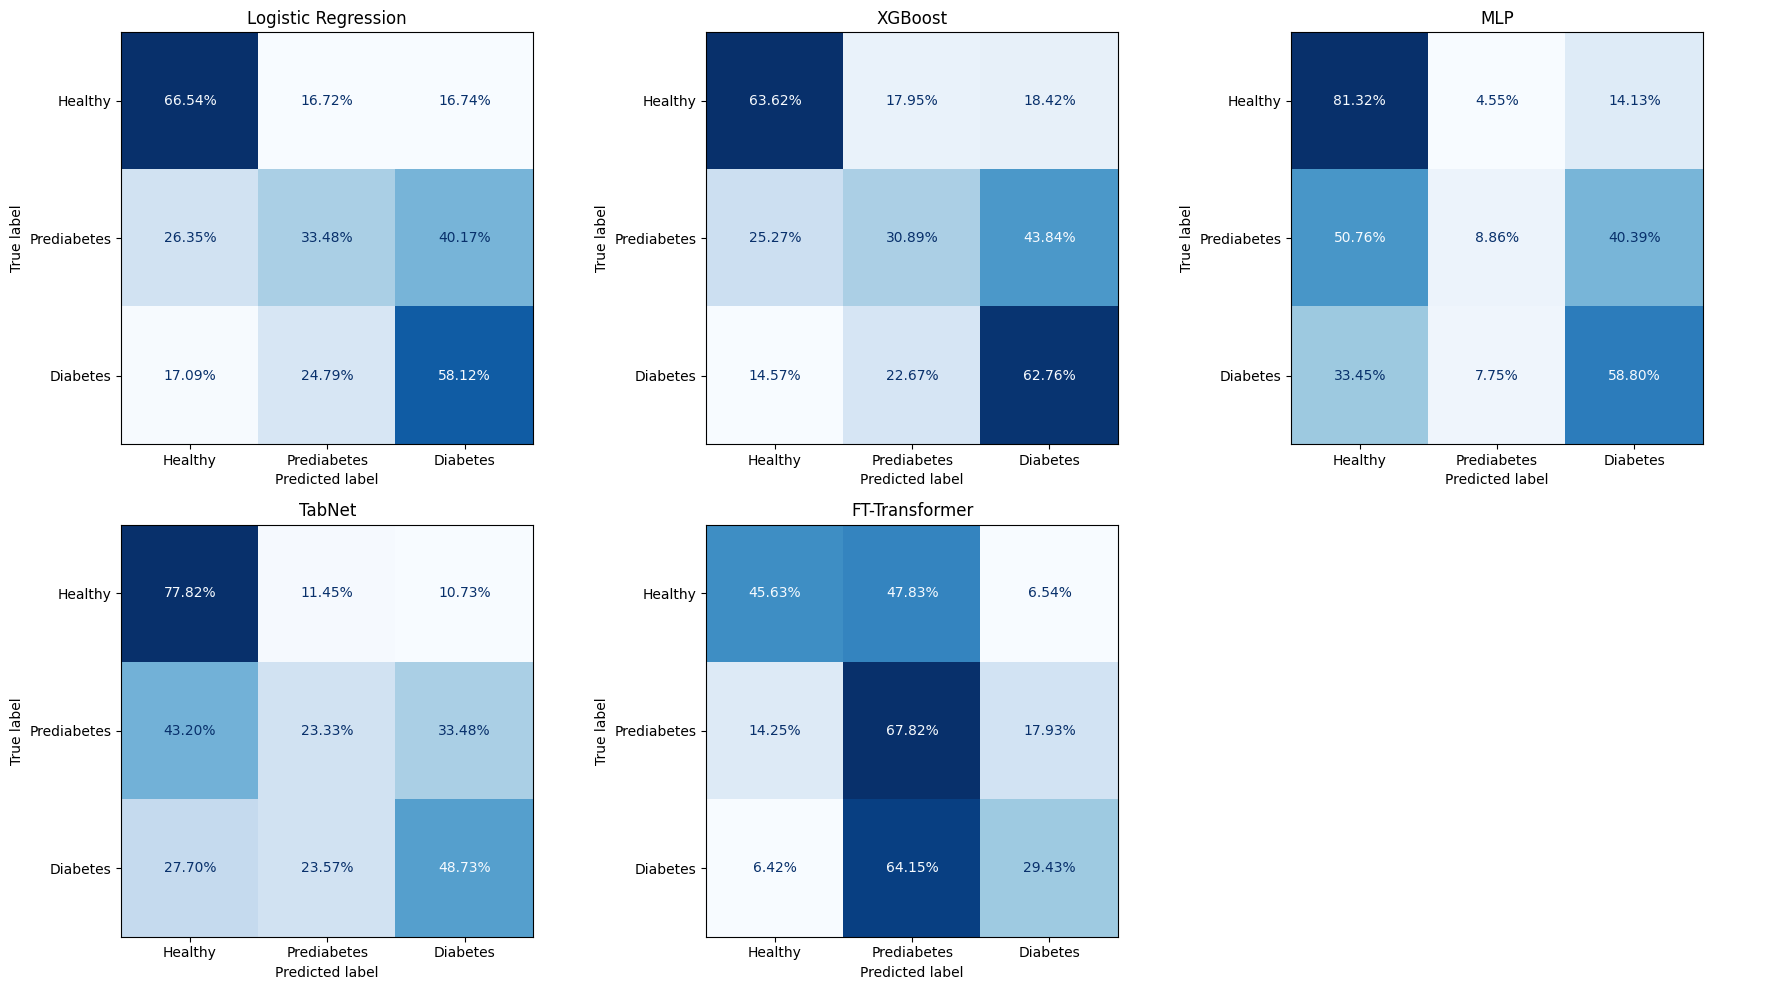

In [151]:
preds_dict = {
    'Logistic Regression': pred_logreg,
    'XGBoost': pred_xgb,
    'MLP': pred_mlp,
    'TabNet': pred_tabnet,
    'FT-Transformer': pred_ftt
}
plot_confusion_matrices(y_test, preds_dict)

The confusion matrices highlight divergent error profiles across architectures. Classical models (Logistic Regression, XGBoost) and the MLP show strong bias toward majority classes, struggling significantly to identify the minority "Prediabetes" group. Conversely, while the FT-Transformer achieves the highest sensitivity for Prediabetes (67.82%), it exhibits notable confusion between the "Prediabetes" and "Diabetes" categories. Overall, these results suggest a performance trade-off: simpler models provide more stable, conservative predictions for dominant health segments, while the FT-Transformer offers superior minority-class detection at the cost of higher inter-class misclassification.

In [152]:
results_df

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (Binary),0.848150,0.709473,0.578874,0.596655,0.817693
1,Logistic Regression (Multiclass),0.846682,0.463673,0.384245,0.393544,0.780802
2,Logistic Regression (Class Weighting),0.645833,0.445365,0.515378,0.426147,0.773534
3,Logistic Regression (SMOTE),0.641379,0.446174,0.515303,0.425020,0.770520
4,Logistic Regression (Class Weighting & Feature...,0.646474,0.445608,0.517109,0.426692,0.773576
5,XGBoost,0.521438,0.513359,0.521438,0.511915,0.712498
6,MLP,0.768606,0.449902,0.496587,0.461159,0.780328
7,Tabnet,0.727688,0.459508,0.499562,0.450658,0.776070
8,FT-Transformer,0.686298,0.440500,0.522431,0.438662,0.776781


## Summary & Conclusions

The evaluation across five distinct architectures, Logistic Regression, XGBoost, MLP, TabNet, and FT-Transformer, reveals a clear performance landscape influenced heavily by class imbalance.

- Baseline Performance: The Logistic Regression (Class Weighting & Feature Selection) baseline remains a robust and computationally efficient model, achieving a competitive Macro F1-score of 0.4267.

- Deep Learning vs. Trees: While the MLP (F1: 0.4612) and TabNet (F1: 0.4507) provided slight improvements over the classical baseline in terms of pure F1-score, they demonstrated significant sensitivity issues in identifying the "Prediabetes" minority class.

- The FT-Transformer achieved an F1-score of 0.4387. The confusion matrices illustrate that this architecture is unique in its ability to capture the Prediabetes signal, achieving the highest recall for that specific class, but it suffers from a high rate of misclassification between "Prediabetes" and "Diabetes," suggesting it struggles to delineate the boundary between high-risk categories despite its superior tokenization of tabular features.

This study demonstrates that addressing the "Accuracy Paradox" via algorithmic class weighting is essential for predictive validity on the BRFSS 2015 dataset. While the MLP and TabNet architectures yielded the highest Macro F1-scores, the trade-off remains significant: these models tend to be more volatile in their inter-class classification compared to the more conservative, stable performance of XGBoost and Logistic Regression.

The FT-Transformer represents a promising direction for minority-class detection; however, its tendency to conflate Prediabetes and Diabetes cases indicates that future work should focus on fine-tuning the model's decision boundaries for ordinal risk categories. For immediate clinical applications where stability and interpretability are paramount, the optimized Logistic Regression or XGBoost models remain the most reliable choices.